# Late Fusion: BERT (text) + ViT (image)

Hateful meme detection with two **genuinely independent** classifiers. A frozen BERT gives a text
vector and a frozen ViT gives an image vector, two backbones that were never trained together, so
there is no shared embedding space.

- **train** - fit the two heads
- **val** - sanity / model-selection signal
- **test** - the reported number

In [1]:
!pip install "transformers>=5.10.2"
!pip install scikit-learn tqdm

In [2]:
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from transformers import AutoModel, AutoTokenizer, AutoImageProcessor
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve
from google.colab import drive, files

## Configuration

In [3]:
TEXT_MODEL  = "bert-base-uncased"
IMAGE_MODEL = "google/vit-base-patch16-224-in21k"
DRIVE_BASE  = "/content/drive/MyDrive/IIS Project/Data"
DEVICE      = "cuda"

DATA_DIR = f"{DRIVE_BASE}/100-samples"
# DATA_DIR = f"{DRIVE_BASE}/full-samples"

EPOCHS = 20
SEED   = 42
torch.manual_seed(SEED)

## Data

Three disjoint splits from the frozen set on Drive. Each split has `<split>.jsonl` beside a
`<split>/images/` folder, and every row's `img` field is `images/<id>.png`.

In [4]:
drive.mount('/content/drive')

def load_split(split):
    with open(f"{DATA_DIR}/{split}.jsonl", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

def load_image(split, row):
    return Image.open(f"{DATA_DIR}/{split}/{row['img']}").convert("RGB")

train_rows = load_split("train")
val_rows   = load_split("val")
test_rows  = load_split("test")

for name, rows in [("train", train_rows), ("val", val_rows), ("test", test_rows)]:
    print(f"{name:5s}: {len(rows):4d} memes | hateful {sum(r['label'] for r in rows)}")

Mounted at /content/drive
train:   70 memes | hateful 35
val  :   10 memes | hateful 5
test :   20 memes | hateful 12


## Features

Two independent frozen backbones as feature extractors. BERT gives a 768-d text vector (its `[CLS]` token) and ViT gives a 768-d image vector. Features are precomputed once per split.

In [5]:
text_tok   = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_model = AutoModel.from_pretrained(TEXT_MODEL).to(DEVICE).eval()
img_proc   = AutoImageProcessor.from_pretrained(IMAGE_MODEL)
img_model  = AutoModel.from_pretrained(IMAGE_MODEL).to(DEVICE).eval()

@torch.no_grad()
def text_features(rows):
    feats = []
    for row in tqdm(rows, desc="BERT text"):
        inp = text_tok(row["text"], return_tensors="pt",
                       truncation=True, max_length=64).to(DEVICE)
        feats.append(text_model(**inp).last_hidden_state[:, 0])   # [CLS]
    return torch.cat(feats).float()

@torch.no_grad()
def image_features(rows, split):
    feats = []
    for row in tqdm(rows, desc="ViT image"):
        inp = img_proc(images=load_image(split, row), return_tensors="pt").to(DEVICE)
        feats.append(img_model(**inp).last_hidden_state[:, 0])    # [CLS]
    return torch.cat(feats).float()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [6]:
Xtr_text, Xtr_img = text_features(train_rows), image_features(train_rows, "train")
Xva_text, Xva_img = text_features(val_rows),   image_features(val_rows,   "val")
Xte_text, Xte_img = text_features(test_rows),  image_features(test_rows,  "test")

ytr = torch.tensor([float(r["label"]) for r in train_rows], device=DEVICE)
yva = [int(r["label"]) for r in val_rows]
yte = [int(r["label"]) for r in test_rows]
print("text dim:", Xtr_text.shape[1], "| image dim:", Xtr_img.shape[1])

BERT text:   0%|          | 0/70 [00:00<?, ?it/s]

ViT image:   0%|          | 0/70 [00:00<?, ?it/s]

BERT text:   0%|          | 0/10 [00:00<?, ?it/s]

ViT image:   0%|          | 0/10 [00:00<?, ?it/s]

BERT text:   0%|          | 0/20 [00:00<?, ?it/s]

ViT image:   0%|          | 0/20 [00:00<?, ?it/s]

text dim: 768 | image dim: 768


## Training

Two independent MLP heads, one per modality.

In [7]:
import copy

class Head(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

@torch.no_grad()
def head_val_auc(head, X, yval):
    return roc_auc_score(yval, torch.sigmoid(head(X)).cpu().tolist())

def train_head(X, y, Xval, yval, epochs=EPOCHS, bs=32, lr=1e-3):
    torch.manual_seed(SEED)
    head = Head(X.shape[1]).to(X.device)
    opt = torch.optim.Adam(head.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    best_auc, best_state = -1.0, None
    for _ in range(epochs):
        head.train()
        perm = torch.randperm(X.shape[0], device=X.device)
        for i in range(0, X.shape[0], bs):
            idx = perm[i:i + bs]
            opt.zero_grad()
            loss_fn(head(X[idx]), y[idx]).backward()
            opt.step()
        head.eval()
        a = head_val_auc(head, Xval, yval)
        if a > best_auc:
            best_auc, best_state = a, copy.deepcopy(head.state_dict())
    head.load_state_dict(best_state)
    return head.eval(), best_auc

text_head,  text_val  = train_head(Xtr_text, ytr, Xva_text, yva)
image_head, image_val = train_head(Xtr_img,  ytr, Xva_img,  yva)
print(f"Heads trained | best val AUROC: text {text_val:.3f} | image {image_val:.3f}")

Heads trained | best val AUROC: text 0.400 | image 0.320


## Results

Text-only and image-only come free from the trained heads. Late fusion is the plain average
`(p_text + p_image) / 2`.

In [8]:
@torch.no_grad()
def head_probs(head, X):
    return torch.sigmoid(head(X)).cpu().tolist()

va_text  = head_probs(text_head,  Xva_text)
va_img   = head_probs(image_head, Xva_img)
va_late  = [(t + i) / 2 for t, i in zip(va_text, va_img)]

p_text  = head_probs(text_head,  Xte_text)
p_image = head_probs(image_head, Xte_img)
p_late  = [(t + i) / 2 for t, i in zip(p_text, p_image)]

In [9]:
def pick_threshold(yval, pval):
    ts = np.linspace(0.05, 0.95, 19)
    return float(max(ts, key=lambda t: f1_score(yval, [int(p >= t) for p in pval])))

def scores(name, pval, ptest):
    t = pick_threshold(yva, pval)
    preds = [int(p >= t) for p in ptest]
    return {
        "model":     name,
        "AUROC":     round(roc_auc_score(yte, ptest), 4),
        "threshold": round(t, 2),
        "Accuracy":  round(accuracy_score(yte, preds), 4),
        "F1":        round(f1_score(yte, preds), 4),
        "n":         len(yte),
    }

def bootstrap_auc_ci(labels, probs, n=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    y, s = np.array(labels), np.array(probs)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    vals = []
    for _ in range(n):
        idx = np.concatenate([rng.choice(pos, len(pos)), rng.choice(neg, len(neg))])
        vals.append(roc_auc_score(y[idx], s[idx]))
    return np.percentile(vals, [2.5, 97.5])

lo, hi = bootstrap_auc_ci(yte, p_late)
print(f"Late-fusion AUROC 95% CI: [{lo:.3f}, {hi:.3f}]")

results = pd.DataFrame([
    scores("BERT text-only",    va_text, p_text),
    scores("ViT image-only",    va_img,  p_image),
    scores("Late fusion (avg)", va_late, p_late),
])
results

Late-fusion AUROC 95% CI: [0.417, 0.917]


,model,AUROC,threshold,Accuracy,F1,n
0,BERT text-only,0.6667,0.05,0.6,0.75,20
1,ViT image-only,0.4792,0.05,0.6,0.75,20
2,Late fusion (avg),0.6875,0.05,0.6,0.75,20


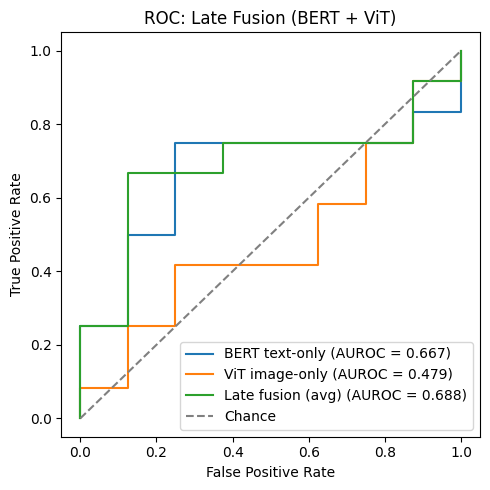

In [10]:
plt.figure(figsize=(5, 5))
for name, probs in [("BERT text-only", p_text),
                    ("ViT image-only", p_image),
                    ("Late fusion (avg)", p_late)]:
    fpr, tpr, _ = roc_curve(yte, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUROC = {roc_auc_score(yte, probs):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Late Fusion (BERT + ViT)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [11]:
pd.DataFrame({
    "id":         [r["id"] for r in test_rows],
    "label":      yte,
    "prob_text":  p_text,
    "prob_image": p_image,
    "prob_late":  p_late,
}).to_csv("late_fusion_predictions.csv", index=False)
files.download("late_fusion_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>